# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [2]:
STUDENT_NAME = "Trần Nhật Trường"  # TODO: Họ và tên
STUDENT_ID = "24120486"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Trần Nhật Trường (24120486)


In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\TranNhatTruong_2026\other\MLIOT_Lab\HW\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [86]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)
print(logits)

[[ 2.000e+00  1.000e+00  1.000e-01]
 [ 1.000e+03  1.001e+03  9.990e+02]
 [-2.000e+00 -1.000e+00  3.000e+00]
 [ 5.000e-01  5.000e-01  5.000e-01]]


In [87]:
# TODO N1
shifted_logits = logits - np.max(logits,axis = 1,keepdims=True )
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits/np.sum(exp_logits,axis =1, keepdims=True)
predicted_classes = np.argmax(class_probabilities,axis=1)
confidence_scores = np.max(class_probabilities,axis=1)
print(predicted_classes)
print(confidence_scores)

[0 1 2 0]
[0.65900114 0.66524096 0.97555875 0.33333333]


In [8]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [10]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [88]:
# TODO N2
train_feature_mean = np.mean(X_train, axis =0)
train_feature_std = np.std(X_train,axis=0)
X_train_scaled = (X_train-train_feature_mean)/train_feature_std
X_val_scaled = (X_val-train_feature_mean)/train_feature_std
print(train_feature_mean)
print(train_feature_std)
print(X_train_scaled)
print(X_val_scaled)


[172.5         69.16666667   1.65        28.16666667]
[ 7.47774476 13.04372987  0.79109629  7.64671316]
[[-0.3343254  -0.31943828 -0.56883088 -0.80644671]
 [ 1.0029762   0.83053953  0.94805147  0.89363014]
 [-1.671627   -1.4694161  -1.07445834 -1.19877214]
 [ 0.3343254   0.06388766 -0.18961029 -0.02179586]
 [-0.60178572 -0.70276422 -0.82164461 -0.54489643]
 [ 1.27043652  1.59719141  1.70649265  1.67828099]]
[[-0.06686508 -0.08944272 -0.31601716 -0.28334614]
 [ 2.34027779  1.98051735  2.21212011  2.20138156]]


In [89]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [90]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [91]:
# TODO N3
correct_mask = (predicted_classes==true_labels)
high_confidence_mask = (confidence_scores>=confidence_threshold)
review_mask = ~(correct_mask & high_confidence_mask)
review_indices = np.where(review_mask)[0]
print(correct_mask)
print(high_confidence_mask)
print(review_mask)
print(review_indices)

[ True False  True False]
[False False  True False]
[ True  True False  True]
[0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [92]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)
print(image_batch_uint8)

[[[[ 0  1  2]
   [ 3  4  5]
   [ 6  7  8]
   [ 9 10 11]]

  [[12 13 14]
   [15 16 17]
   [18 19 20]
   [21 22 23]]

  [[24 25 26]
   [27 28 29]
   [30 31 32]
   [33 34 35]]

  [[36 37 38]
   [39 40 41]
   [42 43 44]
   [45 46 47]]]


 [[[48 49 50]
   [51 52 53]
   [54 55 56]
   [57 58 59]]

  [[60 61 62]
   [63 64 65]
   [66 67 68]
   [69 70 71]]

  [[72 73 74]
   [75 76 77]
   [78 79 80]
   [81 82 83]]

  [[84 85 86]
   [87 88 89]
   [90 91 92]
   [93 94 95]]]]


In [95]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32)/255.0
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0
print(augmented_batch)


[[[[1.         0.03921569 0.04313726]
   [0.02352941 0.02745098 0.03137255]
   [0.01176471 0.01568628 0.01960784]
   [0.         0.00392157 0.00784314]]

  [[0.08235294 0.08627451 0.09019608]
   [0.07058824 0.07450981 0.07843138]
   [0.05882353 0.0627451  0.06666667]
   [0.04705882 0.05098039 0.05490196]]

  [[0.12941177 0.13333334 0.13725491]
   [0.11764706 0.12156863 0.1254902 ]
   [0.10588235 0.10980392 0.11372549]
   [0.09411765 0.09803922 0.10196079]]

  [[0.1764706  0.18039216 0.18431373]
   [0.16470589 0.16862746 0.17254902]
   [0.15294118 0.15686275 0.16078432]
   [0.14117648 0.14509805 0.14901961]]]


 [[[0.22352941 0.22745098 0.23137255]
   [0.21176471 0.21568628 0.21960784]
   [0.2        0.20392157 0.20784314]
   [0.1882353  0.19215687 0.19607843]]

  [[0.27058825 0.27450982 0.2784314 ]
   [0.25882354 0.2627451  0.26666668]
   [0.24705882 0.2509804  0.25490198]
   [0.23529412 0.23921569 0.24313726]]

  [[0.31764707 0.32156864 0.3254902 ]
   [0.30588236 0.30980393 0.3137255 

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**
1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Ký hiệu missing value trong CSV là dấu '?'.
3. Symboling là mức đánh giá rủi ro bảo hiểm.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [ ]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df=='?').sum().sum()
print(raw_df.head(1))
print(raw_shape)
print(raw_missing_marker_count)

   symboling normalized_losses         make fuel_type aspiration num_doors  \
0          3                 ?  alfa-romero       gas        std       two   

    body_style drive_wheels engine_location  wheel_base  ...  engine_size  \
0  convertible          rwd           front        88.6  ...          130   

   fuel_system  bore  stroke compression_ratio horsepower  peak_rpm city_mpg  \
0         mpfi  3.47    2.68               9.0        111      5000       21   

  highway_mpg  price  
0          27  13495  

[1 rows x 26 columns]
(205, 26)
symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore            

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [33]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [102]:
# TODO D2
df_clean = raw_df.replace('?',np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column]=pd.to_numeric(df_clean[column], errors='coerce')
print(df_clean.head(1))
missing_by_column = df_clean.isna().sum()
print(missing_by_column)

   symboling  normalized_losses         make fuel_type aspiration num_doors  \
0          3                NaN  alfa-romero       gas        std       two   

    body_style drive_wheels engine_location  wheel_base  ...  engine_size  \
0  convertible          rwd           front        88.6  ...          130   

   fuel_system  bore  stroke compression_ratio horsepower  peak_rpm city_mpg  \
0         mpfi  3.47    2.68               9.0      111.0    5000.0       21   

   highway_mpg    price  
0           27  13495.0  

[1 rows x 26 columns]
symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore              

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**
Ta không nên fill tất cả numeric columns bằng cùng 1 giá trị vì mỗi cột đại diện cho 1 tính chất khác nhau và nó có miền giá trị khác nhau nên thêm cùng giá trị sẽ làm sai lệch ý nghĩa của số liệu. Với price thì lựa chọn fill cho bài EDA này. Trong bài này chưa biết price có ý nghĩa quan trọng trong thống kê hay xử lí không nhưng thường thì price là 1 thuộc tính hay được dùng và quan trọng nên ở đây giữ lại. Thêm nữa price chỉ có 4 giá trị bị thiếu, rất thấp so với tổng số 205 hàng trong này nên ta nên fill vào. Normalized_losses thiếu nhiều dữ liệu nên khi dùng trực tiếp để phân tích thì có thể làm lệch kết quả vì chỉ còn dữ liệu của các dòng không bị thiếu. Nếu fill thì làm giảm độ biến thiên thật, có thể gây ra phân phối mượt giả.
<!-- Viết 3--6 câu tại đây. -->

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [51]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [103]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype='float64')
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto-auto_feature_mean)/auto_feature_std
print(X_auto_scaled)

[[-0.01548585  0.07625546  0.20296699 -0.65277647 -0.53912772  0.03160942]
 [-0.01548585  0.07625546  0.20296699 -0.65277647 -0.53912772  0.40918671]
 [ 0.51484142  0.60449348  1.35087746 -0.96354805 -0.68549391  0.40918671]
 ...
 [ 0.87932089  1.10872067  0.81696561 -1.11893383 -1.12459248  1.03555038]
 [ 1.27465576  0.43641775  0.06948903  0.12415246 -0.53912772  1.15931531]
 [ 0.97574403  0.34037447  0.28305377 -0.96354805 -0.8318601   1.17879101]]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [104]:
# TODO D4
price_index = 5
price_z = (X_auto[:,price_index]-X_auto[:,price_index].mean())/X_auto[:,price_index].std()
price_outlier_mask = (abs(price_z)>2)
price_outliers = analysis_df[price_outlier_mask]
print(price_outliers)

     curb_weight  engine_size  horsepower  city_mpg  highway_mpg    price
15          3230          209       182.0        16           22  30760.0
16          3380          209       182.0        16           22  41315.0
17          3505          209       182.0        15           20  36880.0
47          4066          258       176.0        15           19  32250.0
48          4066          258       176.0        15           19  35550.0
49          3950          326       262.0        13           17  36000.0
70          3770          183       123.0        22           25  31600.0
71          3740          234       155.0        16           18  34184.0
72          3685          234       155.0        16           18  35056.0
73          3900          308       184.0        14           16  40960.0
74          3715          304       184.0        14           16  45400.0
126         2756          194       207.0        17           25  32528.0
127         2756          194       20

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [140]:
# TODO D5
engine_price_corr = np.corrcoef(X_auto_scaled[:,1],X_auto_scaled[:,5])[0,1]
print(engine_price_corr)

price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()
print(price_by_body_style)

0.8738869517981517
body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

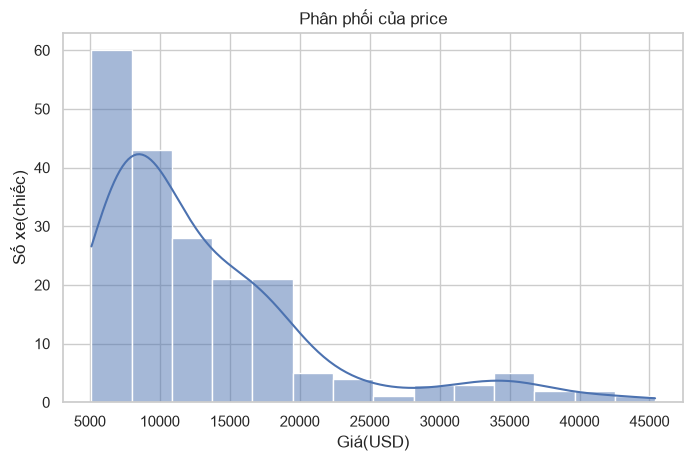

In [134]:
# TODO M2.1: histogram/KDE của price
sns.histplot(data=analysis_df, x='price', kde=True)
plt.xlabel('Giá(USD)')
plt.ylabel('Số xe(chiếc)')
plt.title('Phân phối của price')
plt.show()

**Nhận xét:**
Đồ thị phân phối lệch phải, giá xe tập trung nhiều nhất ở nhóm 10000USD và thấp dần ở 2 bên.

## M2.2 Dataset có cân bằng theo body style không?

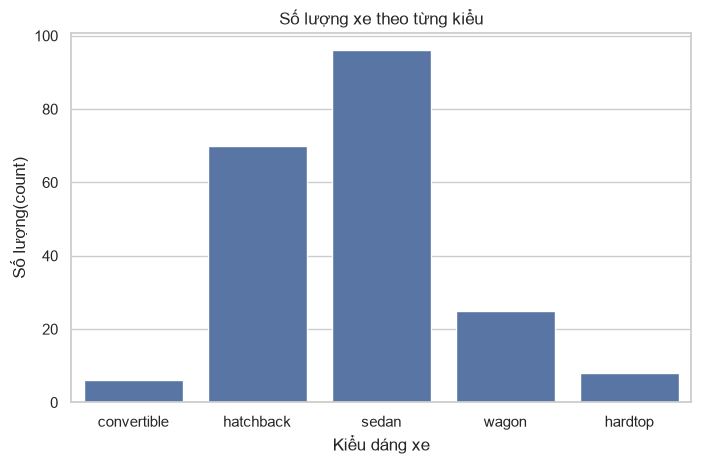

In [110]:
# TODO M2.2: countplot của body_style
sns.countplot(data=df_clean, x= 'body_style')
plt.title('Số lượng xe theo từng kiểu')
plt.xlabel('Kiểu dáng xe')
plt.ylabel('Số lượng(count)')
plt.show()

**Nhận xét:** 
dataset không cân bằng theo body style, số lượng xe kiểu sedan và batchback chiếm đa số trong dataset.

## M2.3 Price khác nhau theo body style ra sao?

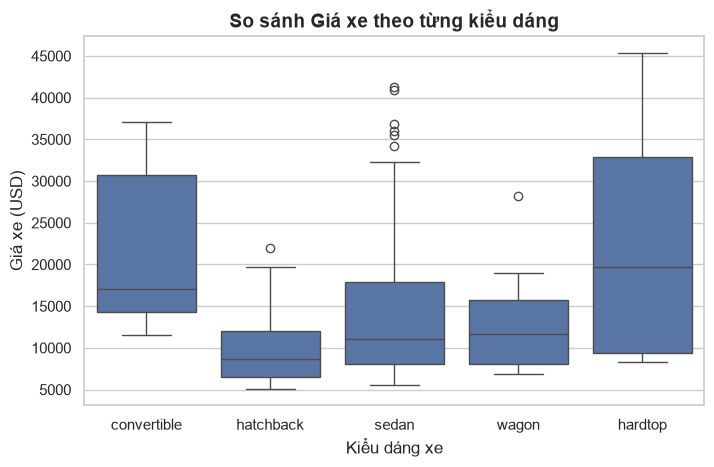

In [112]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=df_clean, x='body_style', y='price')
plt.title('So sánh Giá xe theo từng kiểu dáng', fontsize=14, fontweight='bold')
plt.xlabel('Kiểu dáng xe', fontsize=12)
plt.ylabel('Giá xe (USD)', fontsize=12)
plt.show()

**Nhận xét:** giá trị của hatchback, sedan, wagon phân bố hẹp hơn và thấp hơn so với convertible và hardtop. 

## M2.4 Engine size liên quan thế nào tới price?

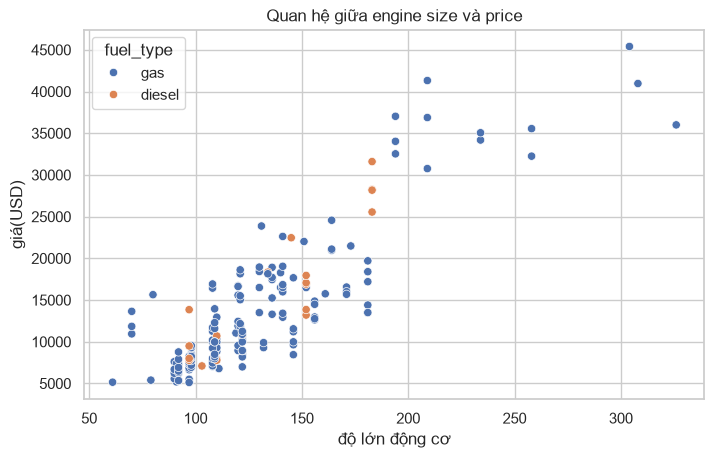

In [117]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(data=df_clean,x='engine_size', y='price', hue='fuel_type')
plt.xlabel('độ lớn động cơ')
plt.ylabel('giá(USD)')
plt.title('Quan hệ giữa engine size và price')
plt.show()

**Nhận xét:** với cả 2 loại nhiên liệu thì đều cho thấy engine_size và price có tương quan dương, khi giá trị của engine_size thì price cũng tăng.

## M2.5 Các feature numeric tương quan ra sao?

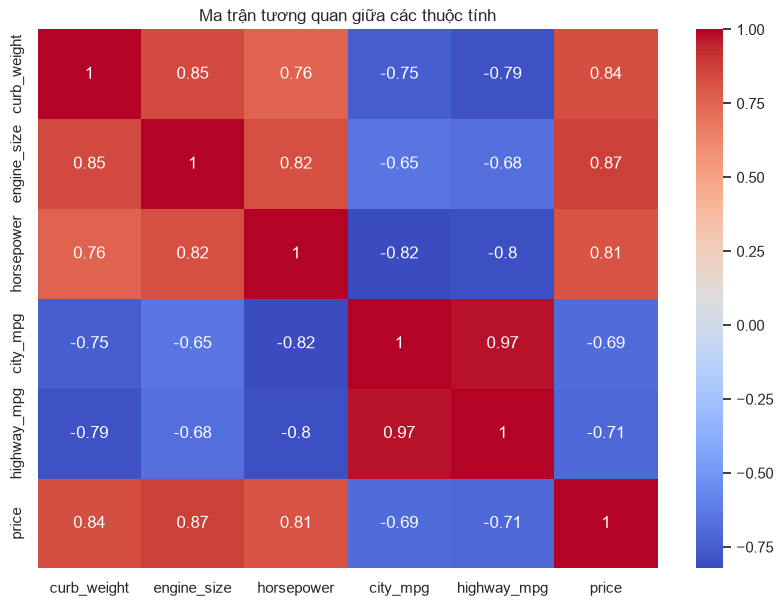

In [127]:
# TODO M2.5: correlation heatmap
# Vì có quá nhiều thuộc tính numeric nên em chỉ dùng các thuộc tính được yêu cầu xử lí trong bài này như trong file data_dictionary để làm
corr = analysis_df.corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Ma trận tương quan giữa các thuộc tính')
plt.show()


**Nhận xét:** ngoài trừ các tương quan với chính nó thì tương quan mạnh nhất là giữa highway_mpg và city_mpg với hệ số là 0.97 và thấp nhất là 0.65 (xét với lấy trị tuyệt đối không phân biệt âm dương)

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

#### câu hỏi: giá trung bình của xe theo từng hãng như thế nào? chênh lệch ra sao?

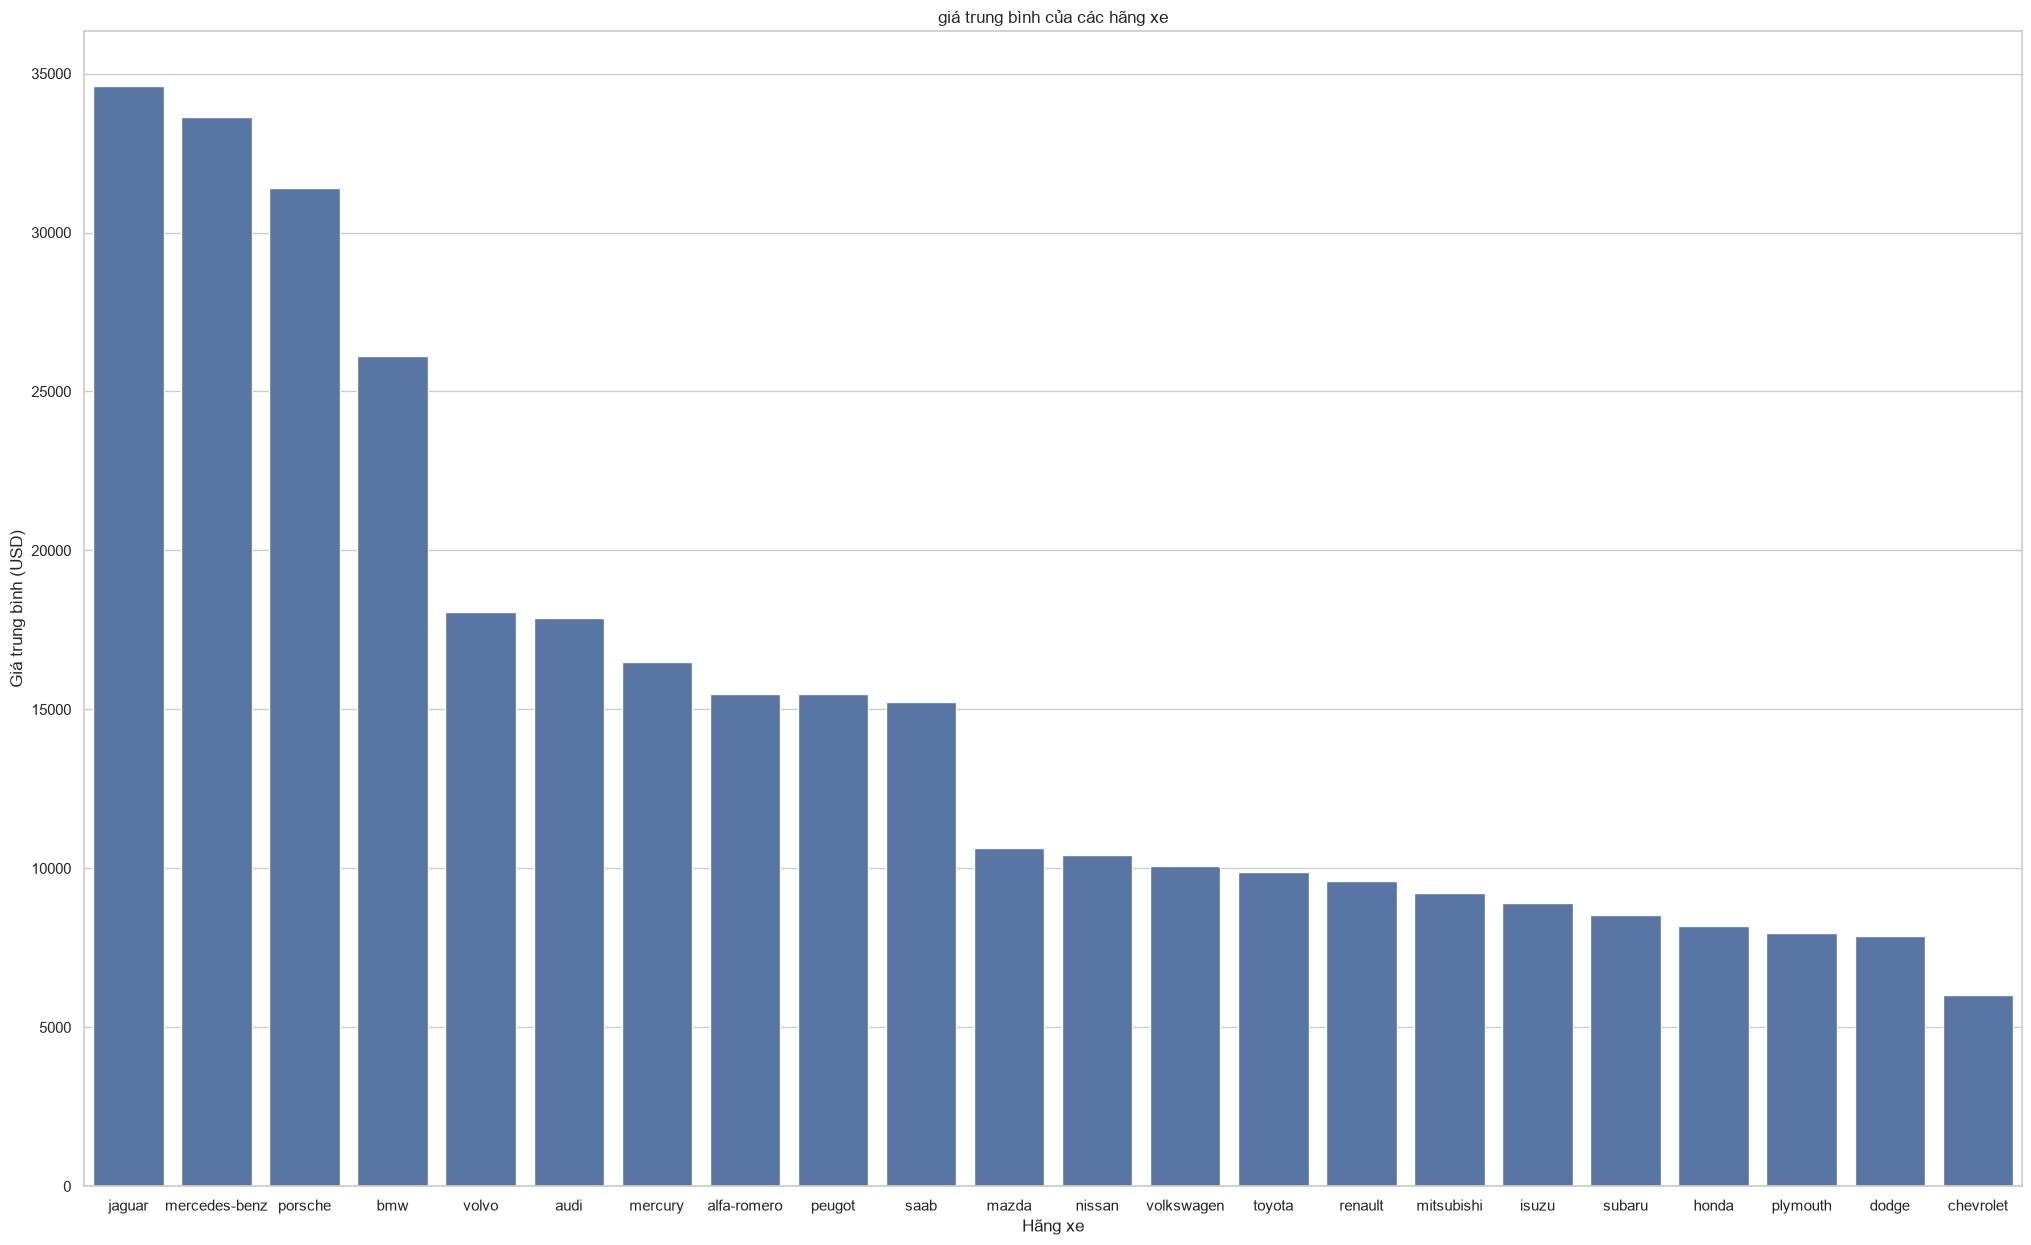

In [141]:
# TODO M2.6: biểu đồ tự chọn
make_price_df = df_clean.dropna(subset=["price"])
avg_price_by_make = (
        make_price_df.groupby("make")["price"].mean().sort_values(ascending=False)
  )
plt.figure(figsize=(25,15))
sns.barplot(
    y=avg_price_by_make.values,
    x=avg_price_by_make.index
)

plt.title("giá trung bình của các hãng xe")
plt.ylabel("Giá trung bình (USD)")
plt.xlabel("Hãng xe")
plt.show()

**Nhận xét:** giá xe trung bình của jaguar là cao nhất và nhỏ nhất là chevrolet

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên
- Price có phân phối lệch phải, phần lớn xe tập trung ở nhóm trung bình thấp, số xe giá cao ít dần. Dataset không cần bằng theo body_style, sedan và hatchback xuất hiện nhiều hơn rỏ rệt. Engine_size, horsepower và curb_weight tương quan mạnh với price. city_mpg và highway_mpg có tương quan mạnh với nhau.
- hạn chế của dataset là có normalized_losses bị thiếu nhiều (41 giá trị). Dữ liệu có body_style không cân bằng nên dễ gây lệch kết quả phân tích.
- engine_size và price tương quan mạnh với nhau nhưng nó vẫn bị phụ thuộc vào các yếu tố khác chứ không phải cứ tăng engine_size thì chắc chắn price sẽ tăng.
- câu hỏi phân tích tiếp theo: Có các thuộc tính nào đa cộng tuyến hay không và có thể bỏ bớt đi các thuộc tính nào mà vẫn giữ được giá trị phân tích của dataset.
